# Schrittweitensteuerung

**Schrittweitensteuerung ist optional, also Zusatzinfo**

Zur Schrittweitensteuerung, d.h. zur Bestimmung der Schrittweite $h$ in jedem Schritt wird eine Fehlerabschätzung, sowie eine Toleranz TOL = $\eta_*$ benötigt. Da der globale Fehler kaum zu schätzen ist, stützt man sich auf den lokalen Fehler $\eta$. Verwendet wird ein Verfahren der Fehlerordnung $p$, d.h. der lokale Fehler skaliert wie 
$$
    h^{p+1} \quad \textrm{d.h.} \quad h \mapsto \alpha \cdot h, \quad \implies \quad \eta \mapsto \eta \cdot \alpha^{p+1}
$$

In jedem Schritt wird dann etwa folgendes gemacht:

* Bestimme einen Kandidaten für $y_{k+1}$ mit der Schrittweite $h$ und schätze den lokalen Fehler $\eta$
* Falls $\eta < \eta_*$, so behalte $y_{k+1}$ andernfalls verwirf es.
* Neue Schrittweite
  $$
      h \mapsto h \cdot \rho \cdot \left( \frac{\eta_*}{\eta}\right)^{\frac{1}{p+1}} \quad \implies \quad
      {\color{blue} \eta \mapsto \eta \cdot \rho^{p+1} \cdot \left(\frac{\eta_*}{\eta}\right)^{\frac{p+1}{p+1}} = \rho^{p+1} \cdot \eta_*}
  $$

D.h. man zielt darauf, im nächsten Schritt gerade einen Fehler $\eta = \eta_*$ zu haben. Der Zusatzfaktor $\rho < 1 $ ist ein Sicherheitsfaktor, der meist konstant, z.B. $\rho = 0.8$ gewählt wird.

Die Schätzung des Fehlers benötigt meist einen Vergleichswert $\hat{y}_{k+1}$, nebst dem eigentlichen $y_{k+1}$.

### Schrittweitensteuerung mit eingebettetem Verfahren
Man verwendet **entweder** ein zweites Verfahren mit einer Fehlerordnung $q < p$ (also ein "schlechteres" Verfahren), und setzt dann einfach

$$
    \eta \approx |y_{k+1} - \hat{y}_{k+1}|
$$

### Schrittweitensteuerung mit Richardson-Extrapolation
**Oder** (wenn man nur ein Verfahren zur Verfügung hat), kann man den Vergleichswert $\hat{y}_{k+1}$ bestimmen, indem man statt einem Schritt der Länge $h$ *zwei* Schritte der Länge $h/2$ macht. Die Erwartung ist dann, dass

$$
    \hat{y}_{k+1} - y_{\textrm{exakt}} = \pm 2^{-p} \cdot (y_{k+1} - y_{\textrm{exakt}})
$$

also

$$
    \hat{y}_{k+1} - y_{k+1} = y_{\textrm{exakt}} - y_{k+1} \pm 2^{-p} \cdot (y_{k+1} - y_{\textrm{exakt}})
$$


$$
    \hat{y}_{k+1} - y_{k+1} = (1 \pm 2^{-p}) \cdot (y_{\textrm{exakt}} - y_{k+1}) \quad \implies \quad 
    \eta \approx \frac{|\hat{y}_{k+1} - y_{k+1}|}{1 \pm 2^{-p}} \leq \frac{|\hat{y}_{k+1} - y_{k+1}|}{1 - 2^{-p}}
$$





## Beispiel: RK4 mit Schrittweitensteuerung durch Richardson-Extrapolation

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Ein Schritt mit RK 4
def RK4step(x, y, f, h):
    r1 = f(x, y)
    r2 = f(x + h/2, y + h/2 * r1)
    r3 = f(x + h/2, y + h/2 * r2)
    r4 = f(x + h,   y + h   * r3)

    return y + h/6 * (r1 + 2 * r2 + 2 * r3 + r4)

In [40]:
# RK4 mit Schrittweitensteuerung
def RK4_sws(f, x0, y0, xn, tol = 1e-5, scaleErr = 1):

    p = 2  # Fehlerordnung für RK 4
    h = (xn - x0) / 100 # Startwert für h
    rho = 0.9 # Sicherheitsfaktor
    
    x = [x0]
    y = [y0]

    while (x[-1] < xn - 1e-10):
        
        y1 = RK4step(x[-1], y[-1], f, h)
    
        y12 = RK4step(x[-1],       y[-1], f, h / 2)
        y22 = RK4step(x[-1] + h/2, y12,   f, h / 2)

        eta = scaleErr * np.linalg.norm(y1 - y22) / (1 - 2**(-p))

        if (eta < tol):
            x.append(x[-1] + h)
            y.append(y22) # wir nehmen den besseren Wert...
            
        h *= rho * (tol / (eta + 1e-5*tol))**(1/(p+1)) # Schrittweite wird in jedem Fall angepasst
        h = min(h, xn - x[-1]) # damit sollten wir die Endstelle nicht überschreiten

    return np.array(x), np.array(y)

In [85]:
# Hilfsfunktion zum plot von Ergebnissen (num Lösung, exakte Lösung, Fehler)
def plotsol(x, y, y_exact):
    fig, ax = plt.subplots(2, 2, figsize = (12, 8), sharex = True)

    a = ax[0][0]
    a.plot(x, y, ".-")
    a.plot(x, y_exact(x), "--", color = "gray")
    a.set_title("RK4")

    a = ax[0][1]
    a.plot(x[:-1], np.diff(x))
    a.set_title("Schrittweiten")

    err = np.abs(y - y_exact(x))
    minErr = np.min(err)
    maxErr = np.max(err)
    a = ax[1][0]
    a.set_title("Fehler")
    a.semilogy(x, err, '.-', label = "Fehler")
    a.hlines(tol, x[0], x[-1], color = "orange", label = "Toleranz")
    a.set_ylim( max( 1e-16, min( minErr, tol) / 2), 2 * max( maxErr, tol)) 
    a.legend()

### Beispiel 1
$$
    y' = - y, \quad y(0) = 1
$$

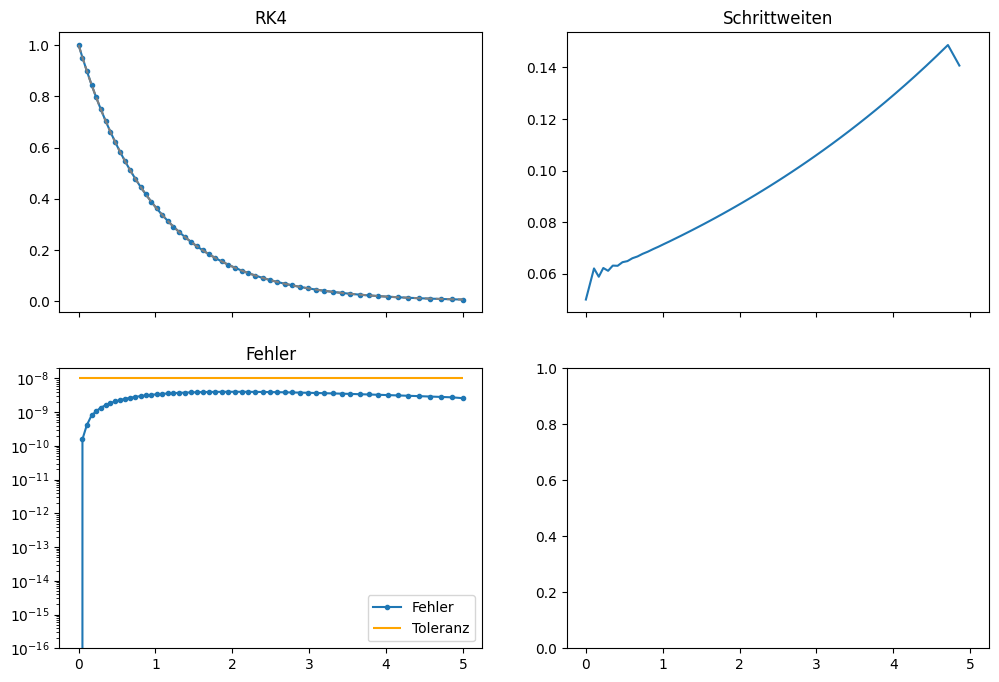

In [86]:
x0 = 0
y0 = 1
xn = 5
tol = 1e-8
f = lambda x, y: - y
y_exact = lambda x: y0 * np.exp(-x)
x, y = RK4_sws(f, x0, y0, xn, tol = tol)

plotsol(x, y, y_exact)

### Beispiel 2
$$
    y' = - \frac{x^2}{y}, \quad y(0) = -4
$$


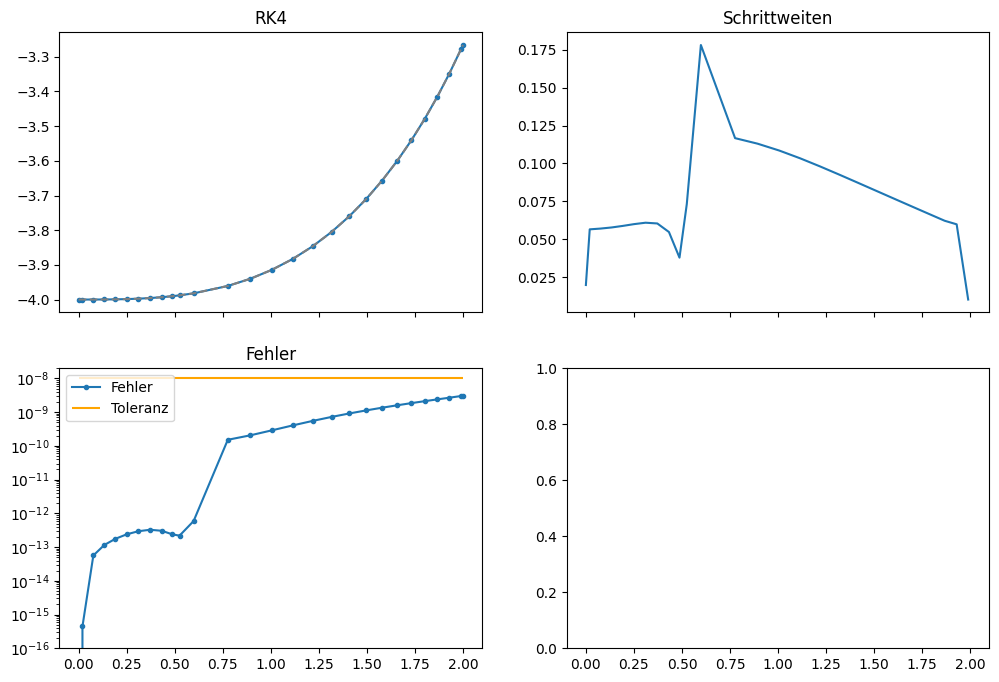

In [88]:
x0 = 0
y0 = -4
xn = 2
tol = 1e-8
f = lambda x, y: -x**2 / y
y_exact = lambda x: -np.sqrt(16 - 2 * x**3/3)

x, y = RK4_sws(f, x0, y0, xn, tol = tol, scaleErr = 1)
plotsol(x, y, y_exact)

### Beispiel 3

$$
    y' = y \cdot (1 - y), \quad y(0) = 10^{-5}
$$

Hier wird der Fehler im steilen Bereich unterschätzt...

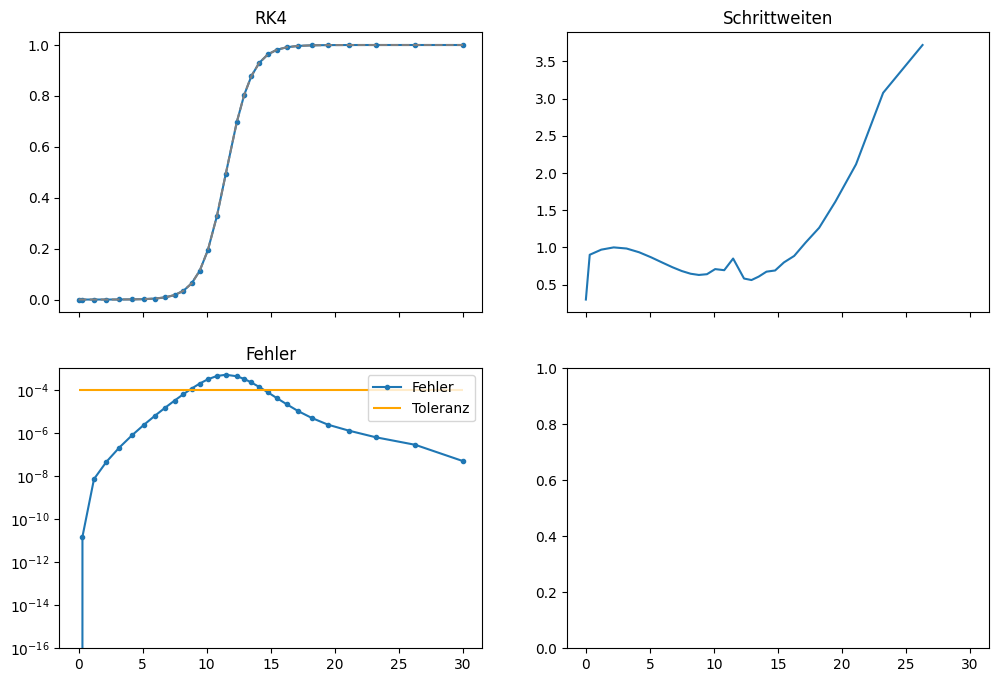

In [89]:
x0 = 0
y0 = 1e-5
xn = 30
tol = 1e-4
f = lambda x, y: y * (1 - y)
y_exact = lambda x: 1 / ((1/y0-1) * np.exp(-x) + 1) 

x, y = RK4_sws(f, x0, y0, xn, tol = tol, scaleErr = 1)
plotsol(x, y, y_exact)